(ch:ml-classification)=
# 분류 프로젝트

이 장에서는 UCI Machine Learning Repository의 레드 와인 품질 데이터셋을 이용하여 품질이 좋은 와인을 찾는 이진 분류 문제를 다룬다. 분류 모델을 훈련하기 전에 데이터의 구조와 분포를 충분히 살펴보고, 정확도뿐 아니라 혼동 행렬, 정밀도, 재현율을 함께 해석한다.

## 프로젝트 흐름

머신러닝 프로젝트는 보통 다음 순서로 진행된다.

1. 문제를 정의한다.
2. 데이터를 불러오고 구조를 확인한다.
3. 탐색적 데이터 분석으로 데이터의 특징을 파악한다.
4. 훈련셋과 테스트셋으로 나눈다.
5. 머신러닝 모델을 훈련한다.
6. 테스트셋으로 모델을 평가한다.
7. 결과를 해석하고 개선 방향을 정한다.

이 장에서는 좋은 와인이 상대적으로 적은 상황에 주목한다. 클래스 비율이 치우친 분류 문제에서는 높은 정확도가 곧 좋은 탐지 성능을 뜻하지 않을 수 있다.

## 데이터셋

와인 품질 데이터셋은 포르투갈 비뉴 베르드 레드 와인의 물리화학적 측정값과 관능 평가 품질 점수를 담고 있다.

| 특성 | 설명 |
| :--- | :--- |
| `fixed acidity` | 고정 산도 |
| `volatile acidity` | 휘발성 산도 |
| `citric acid` | 구연산 함량 |
| `residual sugar` | 잔당 |
| `chlorides` | 염화물 함량 |
| `free sulfur dioxide` | 유리 이산화황 |
| `total sulfur dioxide` | 총 이산화황 |
| `density` | 밀도 |
| `pH` | 산성도 지표 |
| `sulphates` | 황산염 |
| `alcohol` | 알코올 도수 |
| `quality` | 품질 점수(원래 타깃) |

여기서는 `quality >= 7`이면 `good`, 그렇지 않으면 `ordinary`로 정의하여 두 클래스를 예측한다.

머신러닝 프로젝트에 필요한 라이브러리를 불러온다. pandas는 데이터 처리에, matplotlib와 seaborn은 시각화에 사용한다. scikit-learn에서는 데이터 분할, 표준화, 로지스틱 회귀 모델, 평가 지표를 가져온다.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

sns.set_theme(style="whitegrid")

UCI에서 제공하는 CSV 파일을 읽고, 품질 점수를 기준으로 이진 타깃을 만든다. `head()`는 열 이름과 값의 형태를 빠르게 확인하는 데 도움이 된다.

In [2]:
wine_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine_df = pd.read_csv(wine_url, sep=";")

wine_df["quality_label"] = (wine_df["quality"] >= 7).map({True: "good", False: "ordinary"})

X = wine_df.drop(columns=["quality", "quality_label"])
y_quality = wine_df["quality_label"]

wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,ordinary
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,ordinary
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,ordinary
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,ordinary
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,ordinary


## 데이터 구조 확인

먼저 데이터의 크기, 열의 자료형, 결측치, 기본 통계량, 타깃 클래스 구성을 확인한다. 이 단계는 모델을 만들기 전에 데이터가 어떤 모양인지 파악하는 과정이다.

데이터의 행과 열 개수를 확인한다. 관측치 수와 특성 수를 알면 이후 훈련셋과 테스트셋의 크기를 이해하기 쉽다.

In [3]:
wine_df.shape

(1599, 13)

각 열의 자료형과 결측치가 아닌 값의 수를 확인한다. 이 데이터에서는 입력 특성이 수치형인지, 모델링 전에 처리해야 할 비어 있는 값이 있는지 살펴본다.

In [4]:
wine_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
 12  quality_label         1599 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 174.4 KB


열마다 결측치가 몇 개 있는지 계산한다. 결측치가 존재하면 제거하거나 적절한 값으로 대체하는 전처리 방법을 고려해야 한다.

In [5]:
wine_df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
quality_label           0
dtype: int64

수치형 열의 기본 통계량을 확인한다. 특성마다 값의 범위가 크게 다르면 표준화가 필요한 이유를 확인할 수 있고, 품질 점수가 어느 범위에 분포하는지도 알 수 있다.

In [6]:
wine_df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


원래 타깃인 품질 점수의 빈도와, 이진 분류 타깃의 개수 및 비율을 함께 확인한다. `good` 클래스가 적다면 모델 평가는 클래스 불균형을 고려해야 한다.

In [7]:
quality_counts = wine_df["quality"].value_counts().sort_index()
label_summary = pd.DataFrame({
    "count": wine_df["quality_label"].value_counts(),
    "proportion": wine_df["quality_label"].value_counts(normalize=True),
})

quality_counts, label_summary

(quality
 3     10
 4     53
 5    681
 6    638
 7    199
 8     18
 Name: count, dtype: int64,
                count  proportion
 quality_label                   
 ordinary        1382     0.86429
 good             217     0.13571)

## 탐색적 데이터 분석

탐색적 데이터 분석(EDA)은 모델을 훈련하기 전에 데이터의 패턴을 살펴보는 과정이다. 여기서는 다음 질문에 답해 본다.

1. 품질 점수와 이진 클래스는 얼마나 고르게 분포하는가?
2. 좋은 와인과 보통 이하 와인은 주요 물리화학 특성에서 차이가 보이는가?
3. 품질 및 주요 특성 사이의 관계는 어떠한가?
4. 모델 입력으로 사용할 만한 특성은 무엇인가?

원래 품질 점수 분포와 이진 타깃 분포를 막대그래프로 확인한다. 점수 7 이상을 `good`으로 묶었을 때 두 클래스의 불균형이 어떻게 생기는지 시각적으로 확인할 수 있다.

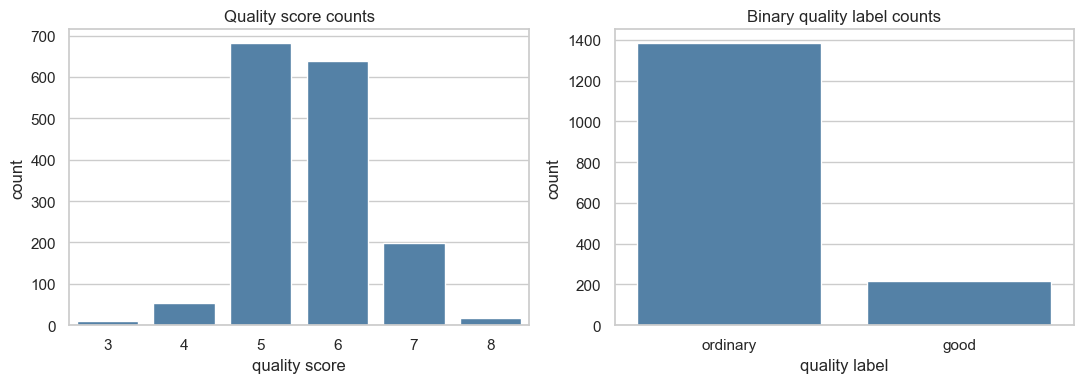

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(data=wine_df, x="quality", ax=axes[0], color="steelblue")
axes[0].set_title("Quality score counts")
axes[0].set_xlabel("quality score")
axes[0].set_ylabel("count")

sns.countplot(data=wine_df, x="quality_label", order=["ordinary", "good"], ax=axes[1], color="steelblue")
axes[1].set_title("Binary quality label counts")
axes[1].set_xlabel("quality label")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

전체 특성을 한꺼번에 해석하기보다는, 품질과 관련이 있을 것으로 예상되는 네 가지 특성을 먼저 자세히 살펴본다. 알코올 도수, 휘발성 산도, 황산염, 밀도는 서로 다른 물리화학적 측면을 나타낸다.

In [9]:
selected_features = [
    "alcohol",
    "volatile acidity",
    "sulphates",
    "density",
]

wine_df[selected_features + ["quality", "quality_label"]].head()

,alcohol,volatile acidity,sulphates,density,quality,quality_label
0,9.4,0.70,0.56,0.9978,5,ordinary
1,9.8,0.88,0.68,0.9968,5,ordinary
2,9.8,0.76,0.65,0.9970,5,ordinary
3,9.8,0.28,0.58,0.9980,6,ordinary
4,9.4,0.70,0.56,0.9978,5,ordinary


선택한 특성의 클래스별 분포를 상자그림으로 비교한다. 상자그림은 두 클래스의 중앙값과 분포 범위가 어느 정도 다르고, 얼마나 겹치는지 보여준다.

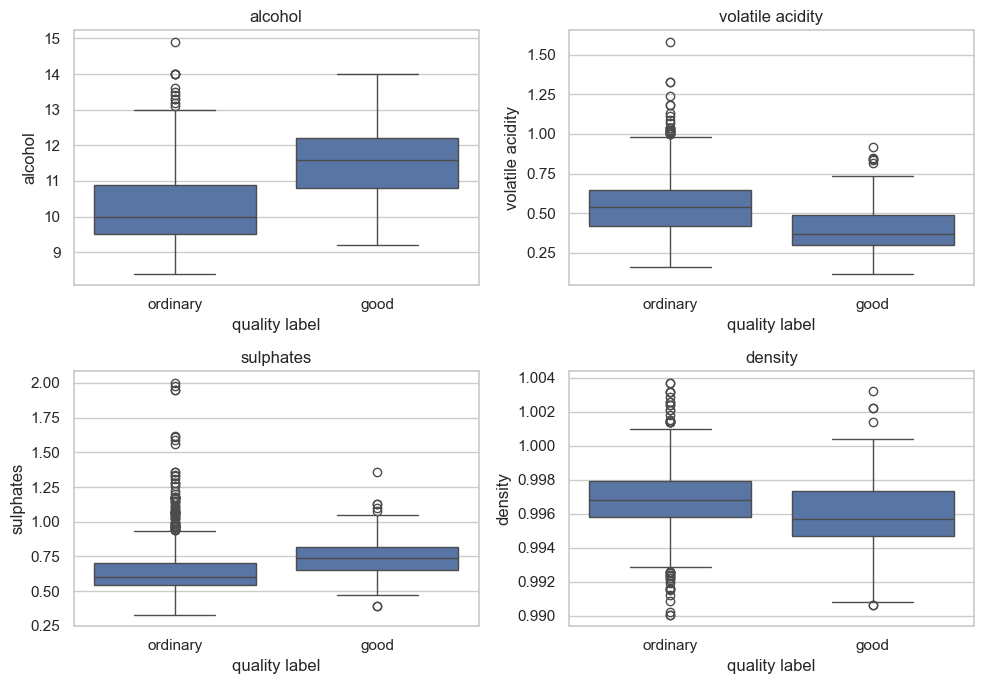

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for feature, ax in zip(selected_features, axes.ravel()):
    sns.boxplot(data=wine_df, x="quality_label", y=feature, order=["ordinary", "good"], ax=ax)
    ax.set_title(feature)
    ax.set_xlabel("quality label")

plt.tight_layout()
plt.show()

알코올 도수와 휘발성 산도의 조합을 산점도로 확인한다. 한 개 특성만 볼 때보다 두 특성을 함께 보았을 때 `good` 와인이 모이는 경향이 있는지 파악할 수 있다.

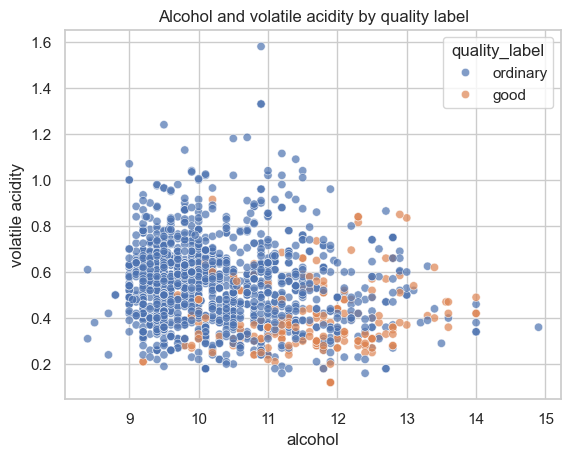

In [11]:
sns.scatterplot(
    data=wine_df,
    x="alcohol",
    y="volatile acidity",
    hue="quality_label",
    hue_order=["ordinary", "good"],
    alpha=0.7,
)
plt.title("Alcohol and volatile acidity by quality label")
plt.show()

수치형 특성들과 원래 품질 점수 사이의 상관계수를 히트맵으로 시각화한다. 상관계수는 선형적인 관계를 요약하므로, 품질과 관련이 큰 후보 특성을 찾는 출발점으로 사용할 수 있다.

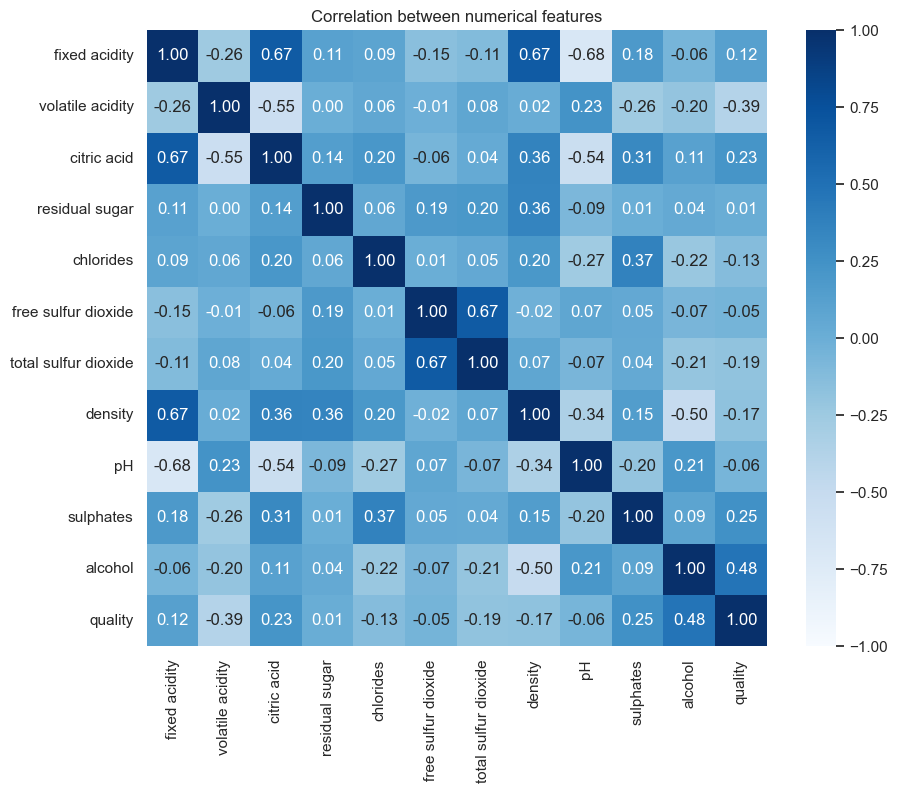

In [12]:
corr = wine_df.drop(columns="quality_label").corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", vmin=-1, vmax=1)
plt.title("Correlation between numerical features")
plt.show()

품질 점수와 각 특성의 상관계수만 따로 정렬하면 어떤 특성이 상대적으로 강한 양의 관계 또는 음의 관계를 갖는지 더 쉽게 비교할 수 있다. 단, 상관관계만으로 품질을 결정하는 원인이라고 결론 내릴 수는 없다.

In [13]:
quality_correlation = (
    corr["quality"]
    .drop("quality")
    .sort_values()
    .rename("correlation_with_quality")
)

quality_correlation.to_frame()

,correlation_with_quality
volatile acidity,-0.390558
total sulfur dioxide,-0.185100
density,-0.174919
chlorides,-0.128907
pH,-0.057731
free sulfur dioxide,-0.050656
residual sugar,0.013732
fixed acidity,0.124052
citric acid,0.226373
sulphates,0.251397


EDA 결과에서 다음을 확인할 수 있다.

- 품질 점수가 7 이상인 `good` 와인은 `ordinary` 와인보다 적어 클래스 불균형이 존재한다.
- `alcohol`과 `sulphates`는 좋은 와인에서 상대적으로 높은 값을 보이는지 살펴볼 수 있는 후보 특성이다.
- `volatile acidity`와 `density`는 클래스에 따라 낮아지는 경향이 있는지 확인할 수 있는 후보 특성이다.
- 각 클래스의 분포가 완전히 분리되지는 않으므로 여러 특성을 함께 사용하는 분류 모델이 필요하다.

이제 관찰한 네 특성을 사용하여 첫 번째 이진 분류 모델을 훈련한다.

## 분류 문제 준비

`quality_label`을 타깃으로 두고, EDA에서 살펴본 네 특성을 입력으로 사용한다. 좋은 와인의 비율이 적으므로 `stratify`를 적용하여 훈련셋과 테스트셋에 비슷한 클래스 비율이 유지되도록 한다.

In [14]:
X_selected = wine_df[selected_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y_quality,
    test_size=0.3,
    random_state=42,
    stratify=y_quality,
)

분할 결과에서 훈련셋과 테스트셋의 클래스 비율이 비슷하게 유지되었는지 확인한다. 이 비율이 크게 달라지면 평가 결과가 우연히 특정 클래스 구성에 영향을 받을 수 있다.

In [15]:
pd.DataFrame({
    "train_proportion": y_train.value_counts(normalize=True),
    "test_proportion": y_test.value_counts(normalize=True),
})

,train_proportion,test_proportion
quality_label,,
ordinary,0.864164,0.864583
good,0.135836,0.135417


특성마다 값의 범위가 다르므로 표준화를 적용한다. 표준화 기준은 훈련셋에서만 계산하고, 테스트셋에는 같은 기준을 적용하여 테스트 정보가 훈련 과정에 섞이지 않도록 한다.

In [16]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=selected_features,
    index=X_train.index,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=selected_features,
    index=X_test.index,
)

표준화된 입력으로 로지스틱 회귀 모델을 훈련한다. 로지스틱 회귀는 각 샘플이 `good` 클래스일 확률을 추정한 뒤 클래스를 예측하는 기본적인 분류 모델이다.

In [17]:
wine_model = LogisticRegression(max_iter=1000)
wine_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## 모델 평가

테스트셋에 대해 예측하고 정확도를 계산한다. 정확도는 전체 샘플 중 맞게 예측한 비율이지만, 클래스 불균형이 있는 이 데이터에서는 다른 지표와 함께 해석해야 한다.

In [18]:
y_pred = wine_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

accuracy

0.8708333333333333

## 혼동 행렬

혼동 행렬은 모델이 어떤 클래스를 어떤 클래스로 예측했는지 보여준다. 실제 `good` 와인을 `ordinary`로 놓친 경우와, 실제 `ordinary` 와인을 `good`으로 잘못 선택한 경우를 구별할 수 있다.

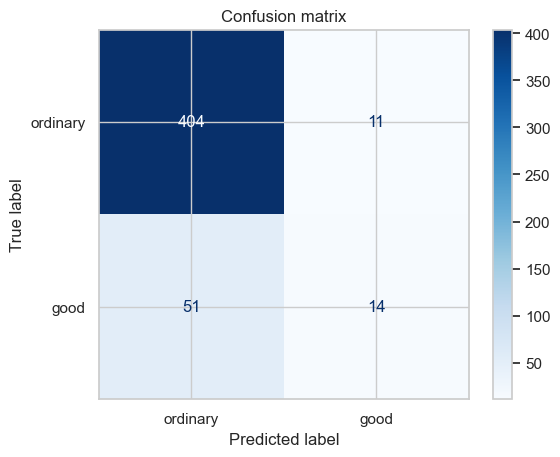

In [19]:
labels = ["ordinary", "good"]
cm = confusion_matrix(y_test, y_pred, labels=labels)

ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap="Blues")
plt.title("Confusion matrix")
plt.show()

## 정밀도와 재현율

정밀도는 모델이 어떤 클래스로 예측한 것 중 실제로 맞은 비율이다. 재현율은 실제 그 클래스인 샘플 중 모델이 찾아낸 비율이다.

좋은 와인을 추천 대상으로 고르는 상황이라면 `good` 정밀도가 중요할 수 있고, 좋은 와인을 최대한 놓치지 않는 것이 목적이라면 `good` 재현율이 더 중요할 수 있다.

In [20]:
print(classification_report(y_test, y_pred, labels=labels))

              precision    recall  f1-score   support

    ordinary       0.89      0.97      0.93       415
        good       0.56      0.22      0.31        65

    accuracy                           0.87       480
   macro avg       0.72      0.59      0.62       480
weighted avg       0.84      0.87      0.85       480



테스트셋의 일부 결과를 실제 클래스, 예측 클래스, `good`일 예측 확률과 함께 정리한다. 확률을 확인하면 모델이 어느 예측에 확신을 보였는지 더 구체적으로 살펴볼 수 있다.

In [21]:
good_index = list(wine_model.classes_).index("good")
results = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred,
    "probability_good": wine_model.predict_proba(X_test_scaled)[:, good_index],
})

results.head(10)

,actual,predicted,probability_good
906,ordinary,ordinary,0.123696
342,ordinary,ordinary,0.088362
981,ordinary,ordinary,0.011861
370,ordinary,ordinary,0.022659
1279,good,ordinary,0.290426
1443,ordinary,ordinary,0.105386
95,ordinary,ordinary,0.317997
213,ordinary,ordinary,0.025681
532,ordinary,ordinary,0.130696
278,good,good,0.713562


## 전체 특성과 비교

이번에는 전체 11개 입력 특성을 사용하여 같은 방식으로 로지스틱 회귀 모델을 훈련한다. EDA에서 선택한 네 특성만 사용했을 때와 전체 정보를 사용했을 때 평가 지표가 어떻게 달라지는지 비교한다.

In [22]:
X_all_train, X_all_test, y_all_train, y_all_test = train_test_split(
    X,
    y_quality,
    test_size=0.3,
    random_state=42,
    stratify=y_quality,
)

all_scaler = StandardScaler()
X_all_train_scaled = all_scaler.fit_transform(X_all_train)
X_all_test_scaled = all_scaler.transform(X_all_test)

wine_all_model = LogisticRegression(max_iter=1000)
wine_all_model.fit(X_all_train_scaled, y_all_train)

y_all_pred = wine_all_model.predict(X_all_test_scaled)

pd.DataFrame(
    {
        "model": ["selected features", "all features"],
        "accuracy": [accuracy, accuracy_score(y_all_test, y_all_pred)],
    }
)

,model,accuracy
0,selected features,0.870833
1,all features,0.883333


전체 특성 모델도 `good` 클래스를 얼마나 잘 찾는지 별도로 살펴보아야 한다. 정확도가 비슷해도 정밀도와 재현율의 균형은 달라질 수 있다.

In [23]:
print(classification_report(y_all_test, y_all_pred, labels=labels))

              precision    recall  f1-score   support

    ordinary       0.90      0.98      0.94       415
        good       0.66      0.29      0.40        65

    accuracy                           0.88       480
   macro avg       0.78      0.63      0.67       480
weighted avg       0.87      0.88      0.86       480



## 정리

이번 장에서는 와인 품질 데이터셋으로 이진 분류 프로젝트의 기본 흐름을 살펴보았다.

- 데이터 구조와 결측치, 통계량을 확인한 뒤 모델링을 시작한다.
- EDA를 통해 타깃 클래스의 불균형과 후보 특성의 분포 차이를 파악할 수 있다.
- 이진 분류는 두 클래스 중 하나를 예측하는 문제이다.
- 클래스 비율이 치우친 데이터에서는 정확도만으로 모델을 평가하기 어렵다.
- 혼동 행렬, 정밀도, 재현율을 함께 보면 모델이 어떤 실수를 하는지 이해할 수 있다.
- 선택한 특성과 전체 특성을 사용한 모델을 비교하면 입력 정보의 효과를 확인할 수 있다.

실제 품질 판별 문제에서는 임계값 조정, 클래스 가중치, 추가 모델 비교 등을 통해 `good` 와인을 찾는 성능을 더 면밀히 개선할 수 있다.

## 연습문제

**문제 1**

`alcohol`, `sulphates` 두 특성만 사용하여 모델을 훈련해 보아라. 네 개 특성을 사용했을 때와 정확도 및 `good` 재현율은 어떻게 달라지는가?

**문제 2**

혼동 행렬에서 모델이 좋은 와인을 얼마나 놓치는지 설명해 보아라. 이 문제에서 좋은 와인을 놓치는 실수가 중요한 이유는 무엇인가?

**문제 3**

`classification_report()`에서 `good`과 `ordinary`의 정밀도와 재현율을 비교해 보아라. 클래스 불균형과 어떤 관련이 있는가?

**문제 4**

`quality >= 6`으로 좋은 와인의 기준을 바꾸면 클래스 분포와 모델 평가 결과는 어떻게 달라지는가?